In [49]:
"""
Imports,
Tokenizer,
Tokenization,
Dataset split,
collate_fn definition,
DataLoaders,
Model definition,
Device setup.
Optimizer,
Training loop,
Validation function,
Convergence detection,
Baseline snapshot,
Compression step,
Recovery training loop
"""

'\nImports,\nTokenizer,\nTokenization,\nDataset split,\ncollate_fn definition,\nDataLoaders,\nModel definition,\nDevice setup.\nOptimizer,\nTraining loop,\nValidation function,\nConvergence detection,\nBaseline snapshot,\nCompression step,\nRecovery training loop\n'

In [50]:
# import os
# os.makedirs('/content/drive/MyDrive/ra1_ffn', exist_ok=True)

In [51]:
# First, mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math
from transformers import AutoTokenizer
from datasets import Dataset
import pandas as pd
from copy import deepcopy

In [53]:
import random
import numpy as np

SEED = 21

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [54]:
df = pd.read_csv('/content/drive/MyDrive/openhermes.csv')
print(len(df))
mid = len(df) // 2
df = df.iloc[:mid]
display(df.head())

242831


,instruction,input,output
0,Write a Perl script that processes a log file ...,NaN,```perl\n#!/usr/bin/perl\n\nuse strict;\nuse w...
1,"What can be seen once in a minute, twice in a ...",NaN,The letter 'M'.
2,Famous inventors and their inventions: Identif...,NaN,1. Thomas Edison: One of his most significant ...
3,Generate a list of 12 words that start with 'qu'.,NaN,1. Quail\n2. Quarry\n3. Quasar\n4. Quench\n5. ...
4,"Who was the first woman to win a Nobel Prize, ...",NaN,Marie Curie; Physics


In [55]:
print(len(df))
mid2 = len(df) // 10
df = df.iloc[:mid2]
print(len(df))

121415
12141


In [56]:
df['input'] = df['input'].fillna("")
df = df.dropna(subset=['output'])

def format_row(row):
    if row["input"].strip() == "":
        return f"### Instruction:\n{row['instruction']}\n\n### Response:\n{row['output']}"
    else:
        return f"### Instruction: /n{row['instruction']}\n\n### Input:\n{row['input']}\n\n### Response:\n {row['output']}"

df['text'] = df.apply(format_row, axis=1)
display(df['text'].head())

,text
0,### Instruction:\nWrite a Perl script that pro...
1,### Instruction:\nWhat can be seen once in a m...
2,### Instruction:\nFamous inventors and their i...
3,### Instruction:\nGenerate a list of 12 words ...
4,### Instruction:\nWho was the first woman to w...


In [57]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    return tokenizer(
        example['text'],
        truncation=True,
        padding="max_length",
        max_length=256
    )

dataset = Dataset.from_pandas(df[['text']])
dataset = dataset.map(tokenize, batched=True)
dataset

Map:   0%|          | 0/12140 [00:00<?, ? examples/s]

Dataset({
    features: ['text', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 12140
})

In [58]:
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [59]:
def collate_fn(batch):
    input_ids = torch.tensor([item["input_ids"] for item in batch])
    attention_mask = torch.tensor([item["attention_mask"] for item in batch])
    return input_ids, attention_mask

# loader = DataLoader(dataset, batch_size=32 ,shuffle=True, collate_fn=collate_fn)

In [60]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [61]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=4,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        seq_len = x.size(1)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device),
            diagonal=1
        ).bool()

        attn_out, _ = self.attn(x, x, x, attn_mask=causal_mask)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

In [62]:
class DecoderOnlyLM(nn.Module):
    def __init__(self, vocab_size, d_model=256, d_ff=1024, n_layers=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, d_ff) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        logits = self.lm_head(x)
        return logits

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = tokenizer.vocab_size
model = DecoderOnlyLM(vocab_size, d_model=256, d_ff=1024)
model.to(device)

DecoderOnlyLM(
  (embed): Embedding(50257, 256)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=256, bias=True)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=50257, bias=True)
)

In [64]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

def train_one_epoch(model, loader, optimizer, vocab_size, device, log_every=50):
    """
    Train the model for one epoch with detailed logging.

    Args:
        model: nn.Module, the model to train
        loader: DataLoader, training data
        optimizer: torch optimizer
        vocab_size: int, size of the tokenizer vocabulary
        device: torch.device
        log_every: int, frequency of logging per batch

    Returns:
        avg_loss: float, average training loss for the epoch
    """
    model.train()
    total_loss = 0

    for step, (input_ids, attention_mask) in enumerate(loader):
        input_ids = input_ids.to(device)

        logits = model(input_ids)
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.reshape(-1, vocab_size),
            shift_labels.reshape(-1),
            ignore_index=tokenizer.pad_token_id
        )

        optimizer.zero_grad()
        loss.backward()

        # Compute gradient norm
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        # Log per batch
        if step % log_every == 0:
            print(f"[Train] Step {step} | Batch Loss: {loss.item():.4f} | Grad Norm: {total_norm:.4f}")

    avg_loss = total_loss / len(loader)
    print(f"[Train] Epoch Average Loss: {avg_loss:.4f}")
    return avg_loss

In [65]:
# Validation function
def evaluate(model, val_loader, vocab_size):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for input_ids, attention_mask in val_loader:
            input_ids = input_ids.to(device)
            logits = model(input_ids)

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()

            loss = F.cross_entropy(
                shift_logits.view(-1, vocab_size),
                shift_labels.view(-1),
                ignore_index=tokenizer.pad_token_id,
                reduction='sum'
            )

            total_loss += loss.item()
            non_pad = (shift_labels != tokenizer.pad_token_id).sum().item()
            total_tokens += non_pad
    model.train()
    return total_loss / total_tokens

In [66]:
def train_until_convergence(model, train_loader, val_loader, optimizer, vocab_size, device, max_epochs=50, patience=3):
    best_val_loss = float('inf')
    epoch_no_improve = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, vocab_size, device)
        val_loss = evaluate(model, val_loader, vocab_size)

        print(f"Epoch {epoch} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss * 0.995:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epoch_no_improve = 0
        else:
            epoch_no_improve += 1

        if epoch_no_improve >= patience:
            print("Converged")
            break
    model.load_state_dict(best_state)
    return best_val_loss

In [67]:
def compress_model_ffn(model, compression_ratio=0.1):
    new_d_ff = int(model.blocks[0].ffn[0].out_features * (1 - compression_ratio))
    print(f"Compressing to {new_d_ff}")
    new_model = DecoderOnlyLM(
        vocab_size,
        d_model=256,
        d_ff=new_d_ff,
        n_layers=len(model.blocks)
    ).to(device)

    # copy embedding + lm_head
    new_model.embed.load_state_dict(model.embed.state_dict())
    new_model.lm_head.load_state_dict(model.lm_head.state_dict())
    new_model.norm.load_state_dict(model.norm.state_dict())

    for old_block, new_block in zip(model.blocks, new_model.blocks):
        # copy attention + norms
        new_block.attn.load_state_dict(old_block.attn.state_dict())
        new_block.norm1.load_state_dict(old_block.norm1.state_dict())
        new_block.norm2.load_state_dict(old_block.norm2.state_dict())

        # FFN pruning
        W1 = old_block.ffn[0].weight.data
        b1 = old_block.ffn[0].bias.data
        W2 = old_block.ffn[2].weight.data
        b2 = old_block.ffn[2].bias.data

        # compute L2 norm of each neuron
        neuron_importance = torch.norm(W2, dim=0)

        # get top-k neurons to keep
        keep_indices = torch.topk(neuron_importance, new_d_ff).indices
        keep_indices, _ = torch.sort(keep_indices)

        # prune W1 rows
        new_block.ffn[0].weight.data.copy_(W1[keep_indices, :])
        new_block.ffn[0].bias.data.copy_(b1[keep_indices])

        # prune W2 columns
        new_block.ffn[2].weight.data.copy_(W2[:, keep_indices])
        new_block.ffn[2].bias.data.copy_(b2)

    return new_model

In [68]:
def recover_after_compression(model, train_loader, val_loader, optimizer, baseline_val_loss, vocab_size, device, max_steps=2000):
    train_iter = iter(train_loader)
    val_loss_trajectory = []
    grad_norm_trajectory = []

    for step in range(max_steps):
        try:
            input_ids, _ = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            input_ids, _ = next(train_iter)

        input_ids = input_ids.to(device)
        logits = model(input_ids)
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.view(-1, vocab_size),
            shift_labels.view(-1),
            ignore_index=tokenizer.pad_token_id,
        )

        optimizer.zero_grad()
        loss.backward()

        # Capture grad norm before clipping
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if step % 100 == 0:
            val_loss = evaluate(model, val_loader, vocab_size)
            val_loss_trajectory.append({'step': step, 'val_loss': val_loss})
            grad_norm_trajectory.append({'step': step, 'grad_norm': total_norm})
            print(f"[Recovery] Step {step} | Val Loss: {val_loss:.4f} | Grad Norm: {total_norm:.4f}")

            if val_loss <= baseline_val_loss * 1.005:
                print("Recovered")
                return True, step, val_loss_trajectory, grad_norm_trajectory

    print("Compression Failed!")
    return False, max_steps, val_loss_trajectory, grad_norm_trajectory

In [69]:
baseline_val_loss = train_until_convergence(model, train_loader, test_loader, optimizer, vocab_size, device)
torch.save(model.state_dict(), f'/content/drive/MyDrive/ra1_ffn/baseline_model_seed{SEED}.pt')
print(f"Baseline Validation Loss: {baseline_val_loss}")

[Train] Step 0 | Batch Loss: 10.9920 | Grad Norm: 1.0059
[Train] Step 50 | Batch Loss: 6.9108 | Grad Norm: 0.5170
[Train] Step 100 | Batch Loss: 6.3416 | Grad Norm: 0.5278
[Train] Step 150 | Batch Loss: 5.7881 | Grad Norm: 0.5600
[Train] Step 200 | Batch Loss: 5.6592 | Grad Norm: 0.5635
[Train] Step 250 | Batch Loss: 5.3308 | Grad Norm: 0.4661
[Train] Step 300 | Batch Loss: 5.0821 | Grad Norm: 0.6121
[Train] Epoch Average Loss: 6.1429
Epoch 0 | Train: 6.1429 | Val: 5.0572
[Train] Step 0 | Batch Loss: 5.0358 | Grad Norm: 0.6429
[Train] Step 50 | Batch Loss: 4.8911 | Grad Norm: 0.5898
[Train] Step 100 | Batch Loss: 4.8814 | Grad Norm: 0.6144
[Train] Step 150 | Batch Loss: 4.9947 | Grad Norm: 0.7832
[Train] Step 200 | Batch Loss: 4.1503 | Grad Norm: 0.9923
[Train] Step 250 | Batch Loss: 4.5043 | Grad Norm: 0.7342
[Train] Step 300 | Batch Loss: 3.9725 | Grad Norm: 0.6476
[Train] Epoch Average Loss: 4.5771
Epoch 1 | Train: 4.5771 | Val: 4.3528
[Train] Step 0 | Batch Loss: 4.1823 | Grad Norm

In [70]:
import json

current_model = model
current_baseline = baseline_val_loss
min_ffn = 64
results = []

while True:
    current_dff = current_model.blocks[0].ffn[0].out_features
    if current_dff <= min_ffn:
        print(f"Stopped: reached structural bottleneck")
        break

    compressed_model = compress_model_ffn(current_model, 0.1)
    new_dff = compressed_model.blocks[0].ffn[0].out_features
    optimizer = torch.optim.AdamW(compressed_model.parameters(), lr=3e-4)

    success, steps_taken, val_trajectory, grad_trajectory = recover_after_compression(
        compressed_model, train_loader, test_loader, optimizer,
        current_baseline, vocab_size, device
    )

    result = {
        'ffn_width': new_dff,
        'recovered': success,
        'recovery_steps_taken': steps_taken,
        'baseline_val_loss': current_baseline,
        'val_loss_trajectory': val_trajectory,
        'grad_norm_trajectory': grad_trajectory
    }
    results.append(result)

    # Save after every compression in case Colab disconnects
    with open(f'/content/drive/MyDrive/ra1_ffn/compression_results_seed{SEED}.json', 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Results saved. FFN {new_dff} | Recovered: {success}")

    if success:
        torch.save(compressed_model.state_dict(),
            f'/content/drive/MyDrive/ra1_ffn/model_seed{SEED}_ffn{new_dff}.pt')
    else:
        break

    current_model = compressed_model
    optimizer = torch.optim.AdamW(current_model.parameters(), lr=3e-4)
    current_baseline = train_until_convergence(
        current_model, train_loader, test_loader,
        optimizer, vocab_size, device, max_epochs=5
    )

Compressing to 921
[Recovery] Step 0 | Val Loss: 3.1071 | Grad Norm: 1.3803
[Recovery] Step 100 | Val Loss: 2.9972 | Grad Norm: 1.1954
[Recovery] Step 200 | Val Loss: 2.9873 | Grad Norm: 1.1777
[Recovery] Step 300 | Val Loss: 2.9796 | Grad Norm: 1.2880
[Recovery] Step 400 | Val Loss: 2.9887 | Grad Norm: 1.2184
[Recovery] Step 500 | Val Loss: 2.9856 | Grad Norm: 1.2059
[Recovery] Step 600 | Val Loss: 2.9796 | Grad Norm: 1.2547
[Recovery] Step 700 | Val Loss: 2.9983 | Grad Norm: 1.2159
[Recovery] Step 800 | Val Loss: 2.9964 | Grad Norm: 1.3279
[Recovery] Step 900 | Val Loss: 2.9936 | Grad Norm: 1.3429
[Recovery] Step 1000 | Val Loss: 3.0090 | Grad Norm: 1.2660
[Recovery] Step 1100 | Val Loss: 3.0131 | Grad Norm: 1.2953
[Recovery] Step 1200 | Val Loss: 3.0174 | Grad Norm: 1.3584
[Recovery] Step 1300 | Val Loss: 3.0296 | Grad Norm: 1.2798
[Recovery] Step 1400 | Val Loss: 3.0350 | Grad Norm: 1.3391
[Recovery] Step 1500 | Val Loss: 3.0355 | Grad Norm: 1.3886
[Recovery] Step 1600 | Val Loss: 

In [71]:
final_val_loss = evaluate(current_model, test_loader, vocab_size)
perplexity = math.exp(final_val_loss)
print(f"Final Validation Loss: {final_val_loss}")
print(f"Perplexity: {perplexity}")

Final Validation Loss: 2.9604072503976773
Perplexity: 19.305832462703975


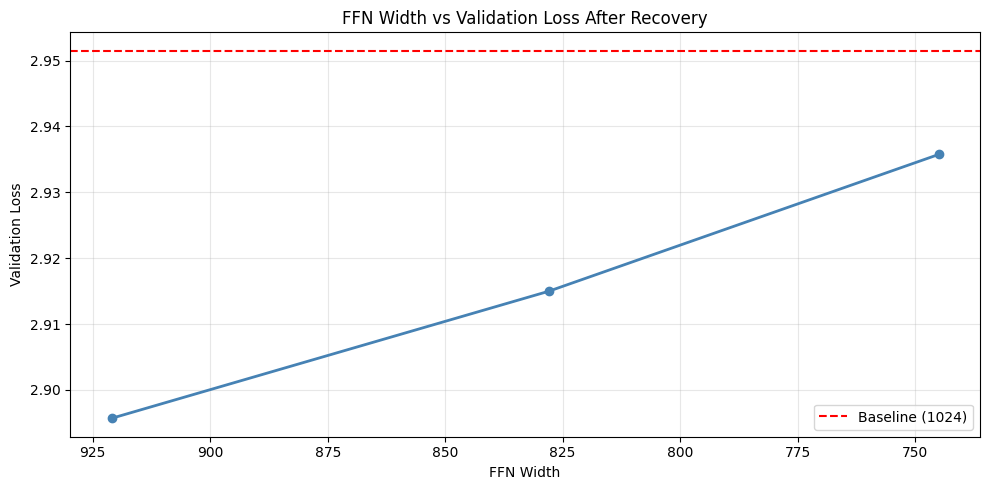

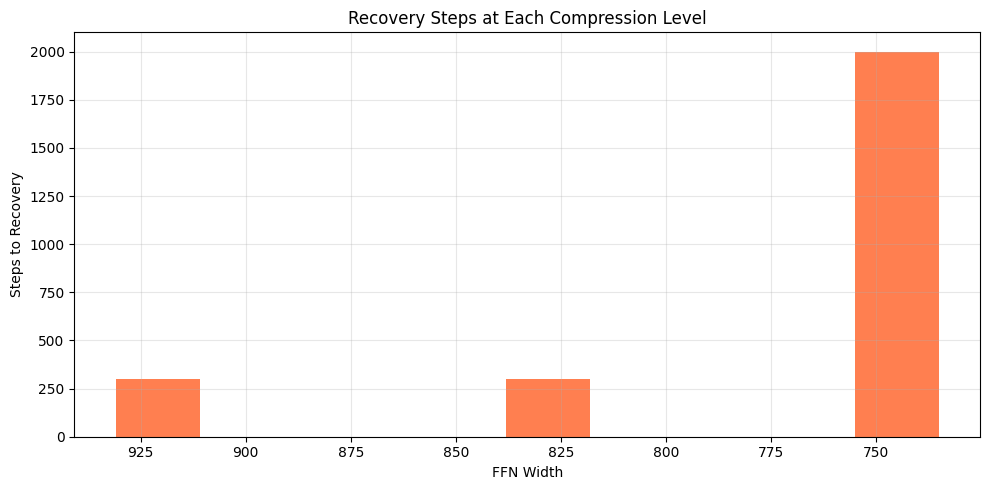

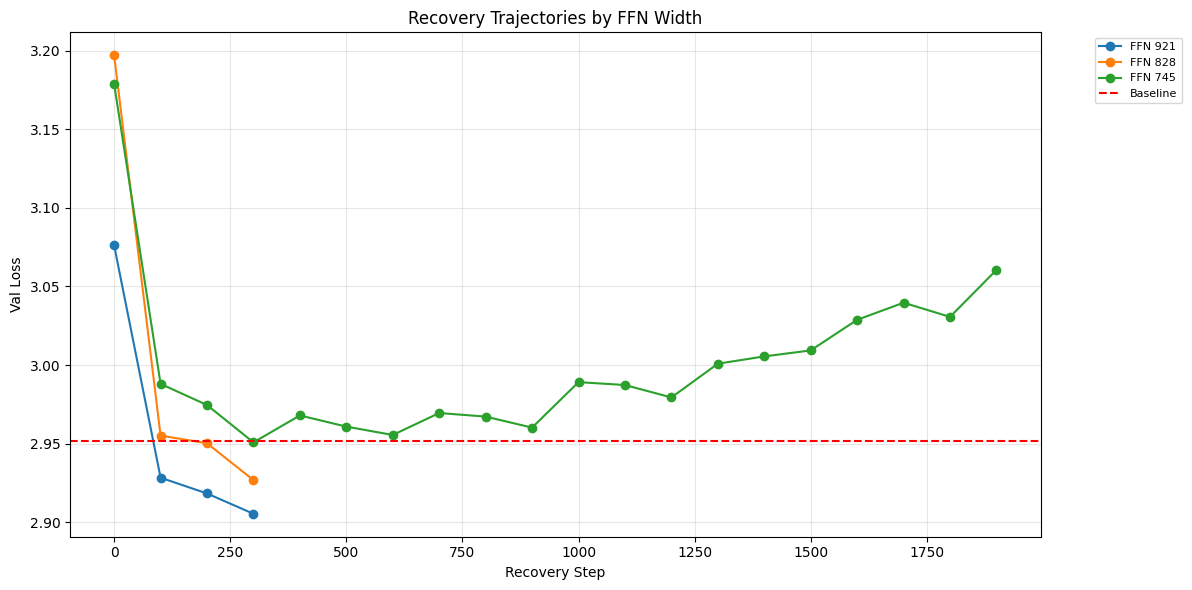

In [72]:
import json
import matplotlib.pyplot as plt

# Load results
with open('/content/drive/MyDrive/ra1_ffn/compression_results.json', 'r') as f:
    results = json.load(f)

# Extract data
ffn_widths = [r['ffn_width'] for r in results]
baseline_losses = [r['baseline_val_loss'] for r in results]

# --- Plot 1: FFN Width vs Val Loss ---
plt.figure(figsize=(10, 5))
plt.plot(ffn_widths, baseline_losses, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=2.9515, color='red', linestyle='--', label='Baseline (1024)')
plt.xlabel('FFN Width')
plt.ylabel('Validation Loss')
plt.title('FFN Width vs Validation Loss After Recovery')
plt.gca().invert_xaxis()  # compression goes left to right
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ra1_ffn/ffn_width_vs_val_loss.png', dpi=150)
plt.show()

# --- Plot 2: Recovery steps per compression ---
recovery_steps = [r['recovery_steps_taken'] for r in results]

plt.figure(figsize=(10, 5))
plt.bar(ffn_widths, recovery_steps, color='coral', width=20)
plt.xlabel('FFN Width')
plt.ylabel('Steps to Recovery')
plt.title('Recovery Steps at Each Compression Level')
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ra1_ffn/recovery_steps.png', dpi=150)
plt.show()

# --- Plot 3: Recovery val loss trajectory for each compression ---
plt.figure(figsize=(12, 6))
for r in results:
    steps = [p['step'] for p in r['val_loss_trajectory']]
    losses = [p['val_loss'] for p in r['val_loss_trajectory']]
    plt.plot(steps, losses, marker='o', label=f"FFN {r['ffn_width']}")

plt.axhline(y=2.9515, color='red', linestyle='--', label='Baseline')
plt.xlabel('Recovery Step')
plt.ylabel('Val Loss')
plt.title('Recovery Trajectories by FFN Width')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ra1_ffn/recovery_trajectories.png', dpi=150)
plt.show()